In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_prior_informed_power(mu, sigma, tau, alpha=0.05):
    """Equation 4: Prior-informed average power closed-form."""
    z_crit = norm.ppf(1 - alpha/2)
    denom = np.sqrt(tau**2 + sigma**2)
    
    term1 = norm.cdf((tau * z_crit - mu) / denom)
    term2 = norm.cdf((-tau * z_crit - mu) / denom)
    return 1 - term1 + term2

# 1. Setup parameters from the paper (Section 3)
# Metric A: Precise but small impacts
mu_a, sigma_a, tau_a = 0, 0.001, 0.002 # [cite: 103]
# Metric B: Noisy but potentially large impacts
mu_b, sigma_b, tau_b = 0, 0.01, 0.005  # [cite: 104]

# 2. Theoretical Calculation
power_a = get_prior_informed_power(mu_a, sigma_a, tau_a)
power_b = get_prior_informed_power(mu_a, sigma_b, tau_b)

# 3. Monte Carlo Simulation (The "Manual" Way)
def run_simulation(mu, sigma, tau, iterations=100000):
    # Step i: Draw true impacts Delta from G [cite: 68]
    true_deltas = np.random.normal(mu, sigma, iterations)
    
    # Step ii/iii: Compute frequentist power for each delta [cite: 70, 72]
    z_crit = norm.ppf(1 - 0.05/2)
    individual_powers = 1 - norm.cdf(z_crit - true_deltas/tau) + norm.cdf(-z_crit - true_deltas/tau)
    
    # Step iv: Average them [cite: 75]
    return np.mean(individual_powers)

sim_power_a = run_simulation(mu_a, sigma_a, tau_a)
sim_power_b = run_simulation(mu_b, sigma_b, tau_b)

print(f"Metric A (Low Var): Theoretical={power_a:.3f}, Simulated={sim_power_a:.3f}")
print(f"Metric B (High Var): Theoretical={power_b:.3f}, Simulated={sim_power_b:.3f}")

Metric A (Low Var): Theoretical=0.080, Simulated=0.080
Metric B (High Var): Theoretical=0.381, Simulated=0.381


<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_28958/3450843194.py:26: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xlabel("Effect Size ($\delta$)", fontsize=12)


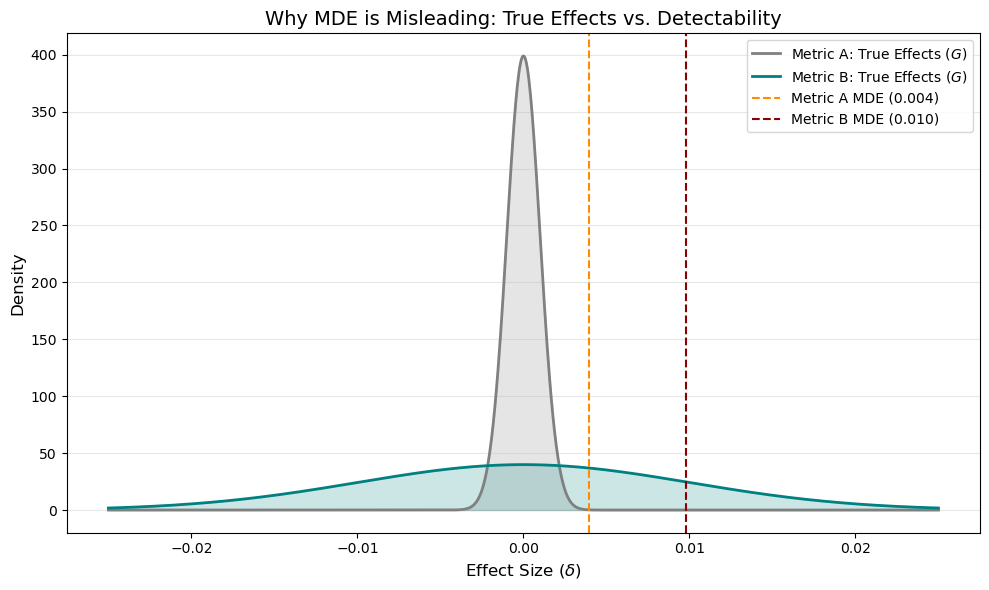

In [2]:
# Calculate MDE for a 5% significance level (standard 1.96 * tau)
mde_a = norm.ppf(0.975) * tau_a
mde_b = norm.ppf(0.975) * tau_b

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-0.025, 0.025, 1000)

# Plot Distribution G for Metric A
y_a = norm.pdf(x, mu_a, sigma_a)
ax.plot(x, y_a, label='Metric A: True Effects ($G$)', color='gray', lw=2)
ax.fill_between(x, y_a, color='gray', alpha=0.2)

# Plot Distribution G for Metric B
y_b = norm.pdf(x, mu_b, sigma_b)
ax.plot(x, y_b, label='Metric B: True Effects ($G$)', color='teal', lw=2)
ax.fill_between(x, y_b, color='teal', alpha=0.2)

# Add MDE lines
ax.axvline(mde_a, color='darkorange', linestyle='--', label=f'Metric A MDE ({mde_a:.3f})')
ax.axvline(mde_b, color='darkred', linestyle='--', label=f'Metric B MDE ({mde_b:.3f})')

# Formatting
ax.set_title("Why MDE is Misleading: True Effects vs. Detectability", fontsize=14)
ax.set_xlabel("Effect Size ($\delta$)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:50: SyntaxWarning: invalid escape sequence '\P'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:50: SyntaxWarning: invalid escape sequence '\P'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_28958/4287245544.py:43: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_title("b) Prior-informed average power $\overline{\Pi}$")
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_28958/4287245544.py:50: SyntaxWarning: invalid escape sequence '\P'
  ax3.set_title("c) Bayesian decision power $\tilde{\Pi}$")


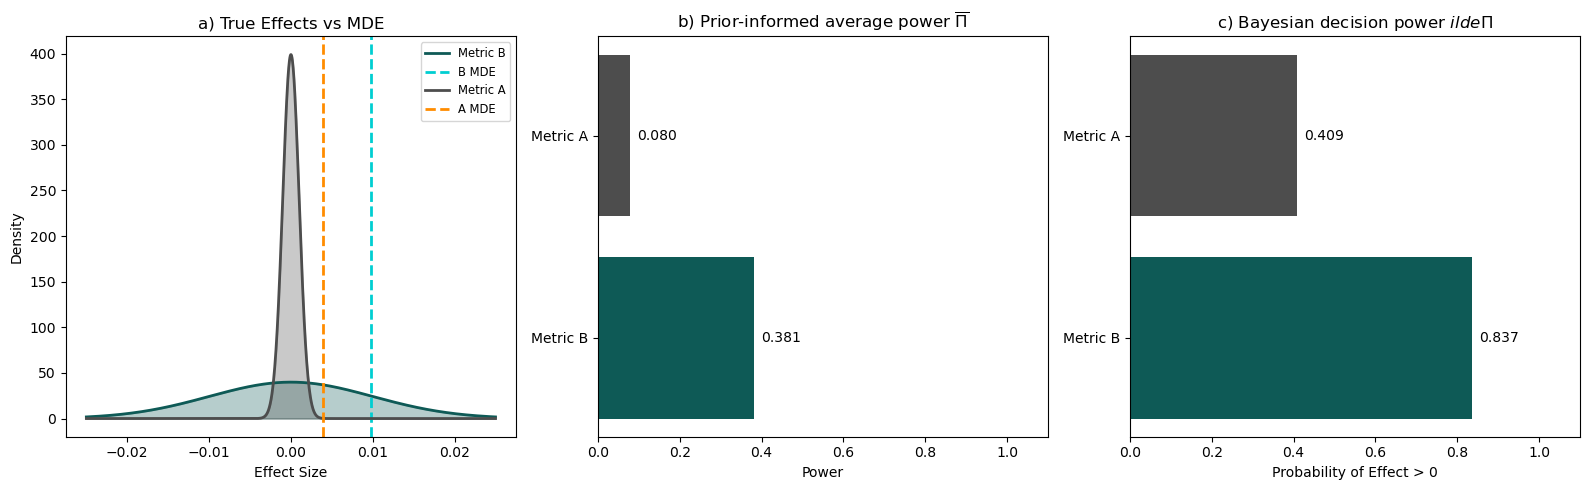

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters from the paper [cite: 103, 104]
params = {
    'A': {'tau': 0.002, 'sigma': 0.001, 'color': '#4d4d4d', 'label': 'Metric A', 'mde_color': '#ff8c00'},
    'B': {'tau': 0.005, 'sigma': 0.01, 'color': '#0e5a56', 'label': 'Metric B', 'mde_color': '#00ced1'}
}
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)

# Calculations for Plot B and C
def get_avg_power(sigma, tau):
    denom = np.sqrt(tau**2 + sigma**2)
    return 1 - norm.cdf((tau*z_crit)/denom) + norm.cdf((-tau*z_crit)/denom)

power_a = get_avg_power(params['A']['sigma'], params['A']['tau']) # ~0.080 [cite: 106, 112]
power_b = get_avg_power(params['B']['sigma'], params['B']['tau']) # ~0.381 [cite: 106, 113]
bayes_a, bayes_b = 0.409, 0.837 # Values from paper [cite: 114, 115]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot A: True Effects vs MDE (The Fix) ---
x = np.linspace(-0.025, 0.025, 1000)
for m in ['B', 'A']: 
    p = params[m]
    mde = z_crit * p['tau']
    # Use the actual PDF so the heights are mathematically correct
    y = norm.pdf(x, 0, p['sigma']) 
    ax1.plot(x, y, color=p['color'], lw=2, label=p['label'])
    ax1.fill_between(x, y, alpha=0.3, color=p['color'])
    # Distinct MDE lines
    ax1.axvline(mde, color=p['mde_color'], linestyle='--', lw=2, label=f'{m} MDE')

ax1.set_title("a) True Effects vs MDE")
ax1.set_xlabel("Effect Size")
ax1.set_ylabel("Density")
ax1.legend(fontsize='small')

# --- Plot B: Prior-informed average power ---
bars2 = ax2.barh(['Metric B', 'Metric A'], [power_b, power_a], color=[params['B']['color'], params['A']['color']])
ax2.set_title("b) Prior-informed average power $\overline{\Pi}$")
ax2.set_xlabel("Power")
ax2.set_xlim(0, 1.1)
ax2.bar_label(bars2, fmt='%.3f', padding=5)

# --- Plot C: Bayesian decision power ---
bars3 = ax3.barh(['Metric B', 'Metric A'], [bayes_b, bayes_a], color=[params['B']['color'], params['A']['color']])
ax3.set_title("c) Bayesian decision power $\tilde{\Pi}$")
ax3.set_xlabel("Probability of Effect > 0")
ax3.set_xlim(0, 1.1)
ax3.bar_label(bars3, fmt='%.3f', padding=5)

plt.tight_layout()
plt.show()

In [6]:

def generate_synthetic_data_flexible_purchase_prob(
    num_individuals=1000,
    num_dates=30,
    purchase_prob_treatment=0.18,
    purchase_prob_control=0.12,
    skewed_revenue=False,
    seed = 21
):
    """
    Generates a synthetic dataset for A/B testing, including individual IDs,
    dates, treatment assignment, purchase indicators, and realized revenue.
   
    The function allows for setting different purchase probabilities for
    treatment and control groups, and offers options for revenue distribution.
   
    Args:
        num_individuals (int): The total number of unique individuals in the dataset.
                               Defaults to 1000.
        num_dates (int): The number of days for which to generate data.
                           Defaults to 30.
        purchase_prob_treatment (float): The probability of an individual in the
                                           'treatment' group making a purchase on any given day.
                                           Must be between 0 and 1. Defaults to 0.18.
        purchase_prob_control (float): The probability of an individual in the
                                         'control' group making a purchase on any given day.
                                         Must be between 0 and 1. Defaults to 0.12.
        skewed_revenue (bool): If True, generates revenue from a highly skewed
                                 (lognormal with specific parameters for more extreme skew)
                                 distribution when a purchase is made. If False, generates
                                 revenue from a less skewed (lognormal with different parameters)
                                 distribution. Defaults to False.
        seed (int): The seed for NumPy's random number generator to ensure
                    reproducibility of the generated data. Defaults to 21.
   
    Returns:
        pandas.DataFrame: A DataFrame with the following columns:
            - 'date' (datetime): The date of the observation.
            - 'individual_id' (str): Unique identifier for each individual.
            - 'treatment' (str): 'treatment' or 'control', indicating group assignment.
            - 'made_purchase' (int): 1 if a purchase was made, 0 otherwise.
            - 'revenue' (float): The realized revenue; 0 if no purchase was made.
    """
    np.random.seed(seed)
    dates = pd.to_datetime(['2025-01-01'] + [pd.Timestamp('2025-01-01') + pd.Timedelta(days=i) for i in range(1, num_dates)])
    individual_ids = [f'ID_{i+1:04d}' for i in range(num_individuals)]
    treatment_assignment = np.random.choice(['treatment', 'control'], size=num_individuals)
 
    data = []
    for date in dates:
        for i in range(num_individuals):
            treatment = treatment_assignment[i]
            if treatment == 'treatment':
                purchase_prob = purchase_prob_treatment
            else:
                purchase_prob = purchase_prob_control
 
            made_purchase = np.random.binomial(1, purchase_prob)
 
            if made_purchase:
                if skewed_revenue:
                    # Highly skewed revenue (lognormal with larger sigma for more extreme values)
                    revenue = np.random.lognormal(mean=0.5, sigma=1.0) * 2
                else:
                    # Less skewed, more 'normal-like' revenue (lognormal with smaller sigma)
                    revenue = np.random.lognormal(mean=2, sigma=0.3)
            else:
                revenue = 0.0
            data.append({
                'date': date,
                'individual_id': individual_ids[i],
                'treatment': treatment,
                'made_purchase': made_purchase,
                'revenue': revenue
            })
 
    return pd.DataFrame(data)


In [9]:
# --- 1. ESTIMATE SAMPLING ERROR (tau) ---
# We run a "A/A test" (no difference) to see the variance of our metrics
aa_data = generate_synthetic_data_flexible_purchase_prob(
    num_individuals=2000, num_dates=14, 
    purchase_prob_treatment=0.12, purchase_prob_control=0.12, 
    skewed_revenue=True
)

def get_metric_stats(df):
    groups = df.groupby('treatment')
    # Conversion Rate
    cr = groups['made_purchase'].mean()
    cr_std = groups['made_purchase'].std() / np.sqrt(len(df)/2)
    # Revenue 
    rev = groups['revenue'].mean()
    rev_std = groups['revenue'].std() / np.sqrt(len(df)/2)
    return {'cr_tau': cr_std.mean(), 'rev_tau': rev_std.mean()}

taus = get_metric_stats(aa_data)

# --- 2. DEFINE BELIEFS (sigma) ---
# Assumption: 
# Most CR wins are tiny (0.1 percentage points) -> sigma = 0.001
# Most Revenue wins are larger ($0.50 spread) -> sigma = 0.50
beliefs = {
    'CR': {'sigma': 0.001, 'tau': taus['cr_tau']},
    'Rev': {'sigma': 0.50, 'tau': taus['rev_tau']}
}

# --- 3. CALCULATE PRIOR-INFORMED POWER ---
def prior_informed_power(mu, sigma, tau, alpha=0.05):
    z_alpha = norm.ppf(1 - alpha/2)
    denom = np.sqrt(tau**2 + sigma**2)
    return 1 - norm.cdf((tau*z_alpha - mu)/denom) + norm.cdf((-tau*z_alpha - mu)/denom)

print(f"--- Prior-Informed Power Comparison ---")
for metric, vals in beliefs.items():
    p = prior_informed_power(0, vals['sigma'], vals['tau'])
    print(f"{metric}: Tau={vals['tau']:.4f}, Sigma={vals['sigma']:.4f} -> Avg Power: {p:.3f}")

--- Prior-Informed Power Comparison ---
CR: Tau=0.0027, Sigma=0.0010 -> Avg Power: 0.066
Rev: Tau=0.0240, Sigma=0.5000 -> Avg Power: 0.925


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# 1. Update the Metric Stats function to include Winsorization (Capping)
def get_metric_stats_with_capping(df, cap_percentile=0.99):
    groups = df.groupby('treatment')
    
    # Raw Revenue Stats
    rev_raw_std = groups['revenue'].std() / np.sqrt(len(df)/2)
    
    # Winsorized Revenue
    cap_value = df['revenue'].quantile(cap_percentile)
    df['revenue_capped'] = df['revenue'].clip(upper=cap_value)
    rev_capped_std = groups['revenue_capped'].std() / np.sqrt(len(df)/2)
    
    return {
        'rev_raw_tau': rev_raw_std.mean(),
        'rev_capped_tau': rev_capped_std.mean(),
        'cap_limit': cap_value
    }

# 2. Run a simulation to see the impact
data = generate_synthetic_data_flexible_purchase_prob(
    num_individuals=5000, num_dates=14, skewed_revenue=True
)

stats = get_metric_stats_with_capping(data)

# 3. Compare Power: Raw vs. Capped
# Assumption: A typical successful feature moves revenue by $0.30 (sigma = 0.3)
sigma_revenue = 0.3 

power_raw = prior_informed_power(0, sigma_revenue, stats['rev_raw_tau'])
power_capped = prior_informed_power(0, sigma_revenue, stats['rev_capped_tau'])

print(f"Revenue Cap Value (99th percentile): ${stats['cap_limit']:.2f}")
print(f"Raw Revenue Tau: {stats['rev_raw_tau']:.4f} -> Power: {power_raw:.3f}")
print(f"Capped Revenue Tau: {stats['rev_capped_tau']:.4f} -> Power: {power_capped:.3f}")

Revenue Cap Value (99th percentile): $14.94
Raw Revenue Tau: 0.0174 -> Power: 0.910
Capped Revenue Tau: 0.0124 -> Power: 0.935
